In [10]:
# this script was written to estimate the PSDs by using window lengths of 200 s and an overlap of 100 s
# PSDs are averged every 3600 s and saved
# instrument is removed afterwards
# cross-crrelations are also estimated every hour using the same window lengths
# same as before the instrument response is removed afterwards

import numpy as np
import scipy.io as sio
from scipy.io import savemat
import scipy.signal as sp
import matplotlib.pyplot as plt
import math as mt
import os.path as op
import obspy
import statistics as st
from obspy.core import read
from obspy.core.trace import Trace
from obspy.core.stream import Stream
from obspy import UTCDateTime
from obspy import read_inventory
from scipy.fft import fft, fftfreq
import datetime
from obspy.clients.filesystem.sds import Client

In [128]:
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)

# read metadata inventory
#respPath = '/dcache/etseis/et/EMR/Stations/NL.TERZ.xml'
respPath = '/dcache/etseis/et/EMR/Stations/Stations/NL.BSDL.xml';
invNow = read_inventory(respPath)
respPathHGN = '/dcache/etseis/et/EMR/Stations/Stations/NL.OBSN.xml'
invHGN = read_inventory(respPathHGN)

azP2 = 0*2*np.pi/360;
azP3 = 0*2*np.pi/360;

# Analyzing January data from 2023
dateStVec = np.array([60])
yearVec = np.array([2026])
nDays = 1;

winLen = 800 # data extraction length
winOv = 400
fSamp = 40;
winAvg = 800; # lets average the PSDs and cross-correlations every four hours
winSave = 86400 # and lets save the matrix of PSDs every day
winLenSamp = int(winLen*fSamp);

dayNow = int(dateStVec[0])
yearNow = yearVec[0]
A = datetime.datetime(yearNow,1,1)+datetime.timedelta(days=dayNow -1)
monthNow = A.month
monthDay = A.day
monthYear = A.year
dateUse = UTCDateTime(monthYear,monthNow,monthDay)

totSegAvg = int(np.floor((winAvg-winOv)/(winLen-winOv)));
totSeg = int(np.floor((86400-winOv)/(winLen-winOv)))
totSegSave = int(np.floor((86400-winOv)/(winLen-winOv)))

xf = fftfreq(winLen*fSamp, 1/fSamp)[:((winLen*fSamp)//2)]
f1 = 0.01; f2=15;
f1Ind = np.argmax(xf>=f1); f2Ind = np.argmax(xf>=f2);
fLen = f2Ind-f1Ind;
startDay = dateUse.julday

#fig, axs = plt.subplots(2, 2, figsize=(16,9))
# create the empty matrices for saving the output


for dayNo in range(0,nDays):
    psdZ0Daily = np.zeros((fLen,totSegSave))
    psdEW0Daily = np.zeros((fLen,totSegSave))
    psdNS0Daily = np.zeros((fLen,totSegSave))
    psdZ1Daily = np.zeros((fLen,totSegSave))
    psdEW1Daily = np.zeros((fLen,totSegSave))
    psdNS1Daily = np.zeros((fLen,totSegSave))
    psdZ2Daily = np.zeros((fLen,totSegSave))
    psdEW2Daily = np.zeros((fLen,totSegSave))
    psdNS2Daily = np.zeros((fLen,totSegSave))
    saveCounter = 0;
    
    for i in range(0,10):
    #for i in range(0,totSeg): # this runs for all the segments
        # check if it is the segment where averaging will stop
        Start = dateUse + i*(winLen-winOv) + (dayNo*86400);
        eTime = Start+winLen;
        dayNow = Start.julday
    
        if(dayNow>startDay):
            # new day
            print('Day '+ str(dayNow) + ' in progress' )
            startDay = dayNow
    
        #print('Reading streams')
        # stream of length winLen seconds
        #stTERZSurf = archive.get_waveforms(station='TERZ',channel='BHZ',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHZ1 = archiveP2.get_waveforms(station='BSDL',channel='BHZ',network='NL',location='01',starttime= Start,endtime=eTime)
        stHHN1 = archiveP2.get_waveforms(station='BSDL',channel='BH1',network='NL',location='01',starttime= Start,endtime=eTime)
        stHHE1 = archiveP2.get_waveforms(station='BSDL',channel='BH2',network='NL',location='01',starttime= Start,endtime=eTime)
    
        #stCTSNSurf = archive.get_waveforms(station='CTSN',channel='BHZ',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHZ0 = archiveP2.get_waveforms(station='BSDL',channel='BHZ',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHN0 = archiveP2.get_waveforms(station='BSDL',channel='BHN',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHE0 = archiveP2.get_waveforms(station='BSDL',channel='BHE',network='NL',location='00',starttime= Start,endtime=eTime)
        
        stHHZ2 = archiveP2.get_waveforms(station='OBSN',channel='BHZ',network='NL',location='01',starttime= Start,endtime=eTime)
        stHHN2 = archiveP2.get_waveforms(station='OBSN',channel='BH1',network='NL',location='01',starttime= Start,endtime=eTime)
        stHHE2 = archiveP2.get_waveforms(station='OBSN',channel='BH2',network='NL',location='01',starttime= Start,endtime=eTime)
    
        #print('Read all streams '+str(i))
        if(stHHZ1 and stHHN1 and stHHE1):
            trace = stHHN1[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHN1 = trace.data;
        
            trace = stHHE1[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHE1 = trace.data;
       
            # apply the rotation
            dataNSNew = dataHHN1[0:winLenSamp]*np.cos(azP2) + dataHHE1[0:winLenSamp]*np.sin(azP2)
            dataEWNew = -dataHHN1[0:winLenSamp]*np.sin(azP2) + dataHHE1[0:winLenSamp]*np.cos(azP2)
        
            trace = stHHZ1[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHZ1 = trace.data;
        
            f2,psdNowHHZ1 = sp.welch(dataHHZ1, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            f2,psdNowHHN1 = sp.welch(dataNSNew, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            f2,psdNowHHE1 = sp.welch(dataEWNew, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            # do ffts for cross-correlations
        
            psdZ1Daily[:,saveCounter] = psdZ1Daily[:,saveCounter]+psdNowHHZ1[f1Ind:f2Ind]
            psdNS1Daily[:,saveCounter] = psdNS1Daily[:,saveCounter]+psdNowHHN1[f1Ind:f2Ind]
            psdEW1Daily[:,saveCounter] = psdEW1Daily[:,saveCounter]+psdNowHHE1[f1Ind:f2Ind]
        
        else:
            print('Borehole has insufficient data')
            goodP2 = 0;
        
        # good for surface data
        if(stHHZ0 and stHHN0 and stHHE0):
            trace = stHHN0[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHN0 = trace.data/10**9;
        
            trace = stHHE0[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHE0 = trace.data/10**9;
        
            trace = stHHZ0[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start,
                       endtime=eTime, pad=True, fill_value=0)
            
            #trace.attach_response(invNow)
            #trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHZ0 = trace.data/10**9;
        
            f2,psdNowHHZ0 = sp.welch(dataHHZ0, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            f2,psdNowHHN0 = sp.welch(dataHHN0, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            f2,psdNowHHE0 = sp.welch(dataHHE0, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            # do ffts for cross-correlations
        
            psdZ0Daily[:,saveCounter] = psdZ0Daily[:,saveCounter]+psdNowHHZ0[f1Ind:f2Ind]
            psdNS0Daily[:,saveCounter] = psdNS0Daily[:,saveCounter]+psdNowHHN0[f1Ind:f2Ind]
            psdEW0Daily[:,saveCounter] = psdEW0Daily[:,saveCounter]+psdNowHHE0[f1Ind:f2Ind]
        
        else:
            print('Surface has insufficient data')
            goodP2 = 0;
            
        if(stHHZ2 and stHHN2 and stHHE2):
            trace = stHHN2[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invHGN)
            trace.remove_response(inventory=invHGN,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHN2 = trace.data;
        
            trace = stHHE2[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invHGN)
            trace.remove_response(inventory=invHGN,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHE2 = trace.data;
       
            # apply the rotation
            dataNSNew = dataHHN2[0:winLenSamp]*np.cos(azP2) + dataHHE2[0:winLenSamp]*np.sin(azP2)
            dataEWNew = -dataHHN2[0:winLenSamp]*np.sin(azP2) + dataHHE2[0:winLenSamp]*np.cos(azP2)
        
            trace = stHHZ2[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            
            trace.attach_response(invHGN)
            trace.remove_response(inventory=invHGN,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHZ2 = trace.data;
        
            f2,psdNowHHZ2 = sp.welch(dataHHZ2, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            f2,psdNowHHN2 = sp.welch(dataNSNew, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            f2,psdNowHHE2 = sp.welch(dataEWNew, fs=fSamp, window='hann', nperseg=100*fSamp, noverlap=50*fSamp, nfft=winLen*fSamp, detrend='linear')
            # do ffts for cross-correlations
        
            psdZ2Daily[:,saveCounter] = psdZ2Daily[:,saveCounter]+psdNowHHZ2[f1Ind:f2Ind]
            psdNS2Daily[:,saveCounter] = psdNS2Daily[:,saveCounter]+psdNowHHN2[f1Ind:f2Ind]
            psdEW2Daily[:,saveCounter] = psdEW2Daily[:,saveCounter]+psdNowHHE2[f1Ind:f2Ind]
        
        else:
            print('Borehole has insufficient data')
            goodP2 = 0;
            
        # reset other quantities
        saveCounter = saveCounter+1

    #totMatFilePathHRBSZ1 = '/data/gravwav/koley/HRBS/AllPSD/HRBSZ1Day'+ str(dayNow) + '.mat'
    #totMatFilePathHRBSNS1 = '/data/gravwav/koley/HRBS/AllPSD/HRBSNS1Day'+ str(dayNow) + '.mat'
    #totMatFilePathHRBSEW1 = '/data/gravwav/koley/HRBS/AllPSD/HRBSEW1Day'+ str(dayNow) + '.mat'

    #totMatFilePathHRBSZ0 = '/data/gravwav/koley/HRBS/AllPSD/HRBSZ0Day'+ str(dayNow) + '.mat'
    #totMatFilePathHRBSNS0 = '/data/gravwav/koley/HRBS/AllPSD/HRBSNS0Day'+ str(dayNow) + '.mat'
    #totMatFilePathHRBSEW0 = '/data/gravwav/koley/HRBS/AllPSD/HRBSEW0Day'+ str(dayNow) + '.mat'
    
    #totMatFilePathHGNZ2 = '/data/gravwav/koley/HRBS/AllPSD/HGNZ2Day'+ str(dayNow) + '.mat'
    #totMatFilePathHGNNS2 = '/data/gravwav/koley/HRBS/AllPSD/HGNNS2Day'+ str(dayNow) + '.mat'
    #totMatFilePathHGNEW2 = '/data/gravwav/koley/HRBS/AllPSD/HGNEW2Day'+ str(dayNow) + '.mat'
    
    #sio.savemat(totMatFilePathHRBSZ1,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyZ1':psdZ1Daily})
    #sio.savemat(totMatFilePathHRBSNS1,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyNS1':psdNS1Daily})
    #sio.savemat(totMatFilePathHRBSEW1,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyEW1':psdEW1Daily})
    #sio.savemat(totMatFilePathHRBSZ0,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyZ0':psdZ0Daily})
    #sio.savemat(totMatFilePathHRBSNS0,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyNS0':psdNS0Daily})
    #sio.savemat(totMatFilePathHRBSEW0,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyEW0':psdEW0Daily})
    #sio.savemat(totMatFilePathHGNZ2,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyZ1':psdZ2Daily})
    #sio.savemat(totMatFilePathHGNNS2,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyNS1':psdNS2Daily})
    #sio.savemat(totMatFilePathHGNEW2,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyEW1':psdEW2Daily})


/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "
/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


Text(0.5, 1.0, 'Jan27, 2025 - Latest')

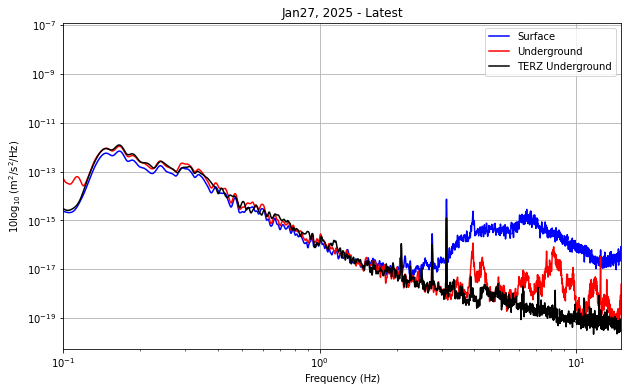

In [130]:
plt.figure(figsize=(10,6))
plt.loglog(f2[f1Ind:f2Ind],psdZ0Daily[:,9],'b',label='Surface')
plt.loglog(f2[f1Ind:f2Ind],psdZ1Daily[:,9],'r',label='Underground')
plt.loglog(f2[f1Ind:f2Ind],psdZ2Daily[:,9],'k',label='TERZ Underground')

plt.xlim(0.1,15)
#plt.xlim(2,8);
#plt.ylim(10**-19,10**-11)
plt.ylabel(r'$10 \log_{10} \; \left( \mathrm{m}^2/\mathrm{s}^2/\mathrm{Hz} \right)$')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.grid()
plt.title('Jan27, 2025 - Latest')

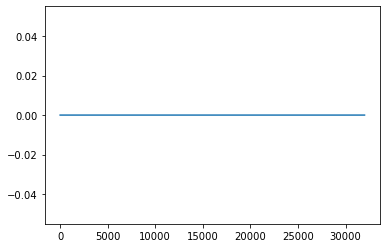

In [127]:
trace = stHHZ1[0];
trace
plt.plot(trace.data)

In [4]:
from obspy import read_inventory
from obspy.core.inventory import Inventory, Network, Station, Channel
from obspy.core.inventory.response import Response, ResponseStage, InstrumentSensitivity

# ----------------------------
# Load generic sensor XML
# ----------------------------
inv_generic = read_inventory("/data/gravwav/koley/HRBS/NL.HRBS.xml")
sensor_response = inv_generic[0][0][0].response  # first channel

# ----------------------------
# Define custom station info
# ----------------------------
network_code = "NL"
station_code = "HRBS"
latitude = 10.0
longitude = 20.0
elevation = 100.0
location_code = "01"  # empty to match traces with empty location
channels = ["BHZ", "BH1", "BH2"]

# ----------------------------
# Digitizer parameters
# ----------------------------
digitizer_gain = 2**24 / 40.0*1400  # replace with actual ADC spec
waveform_in_counts = True      # set False if waveform is already in volts

# ----------------------------
# Create channels with responses
# ----------------------------
channel_objects = []

for ch in channels:
    full_response = Response()

    # Stage 1: Sensor stage (m/s -> V), gain included in XML
    full_response.response_stages.append(sensor_response.response_stages[0])

    # Stage 2: Digitizer stage (V -> counts), only if waveform is in counts
    if waveform_in_counts:
        digitizer_stage = ResponseStage(
            stage_sequence_number=2,
            stage_gain=digitizer_gain,
            stage_gain_frequency=1.0,
            input_units="V",
            output_units="counts"
        )
        digitizer_stage.stage_type = "A/D conversion"
        full_response.response_stages.append(digitizer_stage)

    # ----------------------------
    # Set top-level InstrumentSensitivity
    # ----------------------------
    full_response.instrument_sensitivity = InstrumentSensitivity(
        value=1.0,  # gain already included in stages
        frequency=1.0,
        input_units=full_response.response_stages[0].input_units,
        output_units=full_response.response_stages[-1].output_units
    )

    # Create the channel and attach response
    channel = Channel(
        code=ch,
        location_code=location_code,
        latitude=latitude,
        longitude=longitude,
        elevation=elevation,
        depth=0.0,
        response=full_response,
        start_date=None,   # Always active
        end_date=None      # Always active
    )
    channel_objects.append(channel)

# ----------------------------
# Create Station and Network
# ----------------------------
station = Station(
    code=station_code,
    latitude=latitude,
    longitude=longitude,
    elevation=elevation,
    channels=channel_objects,
    start_date=None,  # Always active
    end_date=None
)

network = Network(network_code, stations=[station])
custom_inventory = Inventory(networks=[network], source="User")

# ----------------------------
# Write StationXML
# ----------------------------
custom_inventory.write("/data/gravwav/koley/HRBS/myHRBS_final.xml", format="STATIONXML")


In [5]:
#respPath = '/dcache/etseis/et/EMR/Stations/NL.TERZ.xml'
respPath = '/data/gravwav/koley/HRBS/myHRBS_final.xml';
invNow = read_inventory(respPath)
ch = invNow[0][0][0]  # first network, first station, first channel
print(ch.response)

Channel Response
	From m/s (None) to counts (None)
	Overall Sensitivity: 1 defined at 1.000 Hz
	2 stages:
		Stage 1: PolesZerosResponseStage from m/s to V, gain: 754.3
		Stage 2: ResponseStage from V to V, gain: 5.87203e+08


In [29]:
trace.stats

         network: NL
         station: HRBS
        location: 01
         channel: BH1
       starttime: 2025-09-17T00:00:00.000000Z
         endtime: 2025-09-17T00:13:20.000000Z
   sampling_rate: 40.0
           delta: 0.025
            npts: 32001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 1, 'encoding': 'STEIM1', 'byteorder': '>', 'record_length': 512, 'filesize': 3233792})
      processing: ['ObsPy 1.3.0: trim(endtime=None::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2025, 9, 17, 0, 0))', 'ObsPy 1.3.0: trim(endtime=UTCDateTime(2025, 9, 17, 0, 13, 20)::fill_value=None::nearest_sample=True::pad=False::starttime=None)', 'ObsPy 1.3.0: trim(endtime=UTCDateTime(2025, 9, 17, 0, 13, 20)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2025, 9, 17, 0, 0))', 'ObsPy 1.3.0: trim(endtime=UTCDateTime(2025, 9, 17, 0, 13, 20)::fill_value=0::nearest_sample=True::pad=True::star

In [39]:
respPath = '/dcache/etseis/et/EMR/Stations/NL.TERZ.xml'
#respPath = '/data/gravwav/koley/HRBS/myHRBS_final.xml';
invN = read_inventory(respPath)
ch = invN[0][0][0]  # first network, first station, first channel
print(ch.response)

Channel Response
	From M/S (None) to COUNTS (None)
	Overall Sensitivity: 1.9024e+10 defined at 1.000 Hz
	7 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 1189
		Stage 2: PolesZerosResponseStage from V to V, gain: 40
		Stage 3: CoefficientsTypeResponseStage from V to COUNTS, gain: 400000
		Stage 4: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 5: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 6: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 7: FIRResponseStage from COUNTS to COUNTS, gain: 1


/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


In [11]:
stHHZ1

1 Trace(s) in Stream:
NL.HRBS.01.BHZ | 2025-09-17T00:00:00.000000Z - 2025-09-17T00:13:20.000000Z | 40.0 Hz, 32001 samples

In [13]:
trace

NL.HGN.02.BHZ | 2025-09-16T23:59:59.994539Z - 2025-09-17T00:13:19.994539Z | 40.0 Hz, 32001 samples

In [4]:
totMatFilePathHRBSZ1 = '/data/gravwav/koley/HRBS/AllPSD/HRBSZ1Day'+ str(dayNow) + '.mat'
totMatFilePathHRBSNS1 = '/data/gravwav/koley/HRBS/AllPSD/HRBSNS1Day'+ str(dayNow) + '.mat'
totMatFilePathHRBSEW1 = '/data/gravwav/koley/HRBS/AllPSD/HRBSEW1Day'+ str(dayNow) + '.mat'

totMatFilePathHRBSZ0 = '/data/gravwav/koley/HRBS/AllPSD/HRBSZ0Day'+ str(dayNow) + '.mat'
totMatFilePathHRBSNS0 = '/data/gravwav/koley/HRBS/AllPSD/HRBSNS0Day'+ str(dayNow) + '.mat'
totMatFilePathHRBSEW0 = '/data/gravwav/koley/HRBS/AllPSD/HRBSEW0Day'+ str(dayNow) + '.mat'
    
    
totMatFilePathHGNZ2 = '/data/gravwav/koley/HRBS/AllPSD/HGNZ2Day'+ str(dayNow) + '.mat'
totMatFilePathHGNNS2 = '/data/gravwav/koley/HRBS/AllPSD/HGNNS2Day'+ str(dayNow) + '.mat'
totMatFilePathHGNEW2 = '/data/gravwav/koley/HRBS/AllPSD/HGNEW2Day'+ str(dayNow) + '.mat'
    
sio.savemat(totMatFilePathHRBSZ1,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyZ1':psdZ1Daily})
sio.savemat(totMatFilePathHRBSNS1,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyNS1':psdNS1Daily})
sio.savemat(totMatFilePathHRBSEW1,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyEW1':psdEW1Daily})
sio.savemat(totMatFilePathHRBSZ0,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyZ0':psdZ0Daily})
sio.savemat(totMatFilePathHRBSNS0,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyNS0':psdNS0Daily})
sio.savemat(totMatFilePathHRBSEW0,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyEW0':psdEW0Daily})
sio.savemat(totMatFilePathHGNZ2,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyZ1':psdZ2Daily})
sio.savemat(totMatFilePathHGNNS2,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyNS1':psdNS2Daily})
sio.savemat(totMatFilePathHGNEW2,mdict={'freq':xf[f1Ind:f2Ind],'psdDailyEW1':psdEW2Daily})

In [51]:
for net in invNow:
    for sta in net:
        for cha in sta:
            if sta.code == "BSDL" and cha.location_code == "02":
                print(
                    cha.code,
                    "location:", cha.location_code,
                    "depth:", cha.depth,
                    "elevation:", cha.elevation,
                    "latitude:", cha.latitude,
                    "longitude:", cha.longitude,
                )

BH1 location: 02 depth: 30.0 elevation: 169.0 latitude: 50.75214 longitude: 5.909763
BH2 location: 02 depth: 30.0 elevation: 169.0 latitude: 50.75214 longitude: 5.909763
BHZ location: 02 depth: 30.0 elevation: 169.0 latitude: 50.75214 longitude: 5.909763
HH1 location: 02 depth: 30.0 elevation: 169.0 latitude: 50.75214 longitude: 5.909763
HH2 location: 02 depth: 30.0 elevation: 169.0 latitude: 50.75214 longitude: 5.909763
HHZ location: 02 depth: 30.0 elevation: 169.0 latitude: 50.75214 longitude: 5.909763


In [73]:
respPath = '/dcache/etseis/et/EMR/Stations/Stations/NL.TERZ.xml';
invNow = read_inventory(respPath)
sta = invNow.select(network="NL", station="TERZ")[0][0]

print("Station latitude:", sta.latitude)
print("Station longitude:", sta.longitude)

Station latitude: 50.756763
Station longitude: 5.906114


/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "
